# Carreguem  el DataFrame principal modificat amb les dades netejades i transformades

In [2]:
# Carreguem  el DataFrame principal modificat amb les dades netejades i transformades
import pandas as pd
df_principal = pd.read_excel('C:\\temp\\df_principal_modificat.xlsx')
df_principal.head(5)

,IDALUMNE,IDCURS,IDEVALUACIO,MATERIA,RESULT,PUNTS,MAXPUNTS,POBLACIO,PAIS,DATANAIXEMENT,SEXO,NRO_EJERCICIO,TOTAL,TIPUS_ESCOLA,PROFE,INICI_CURS,EDAD,DATA_EVALUACIO
0,30,788,53,LISTENING,18.8,16.0,17.0,Barcelona,Espanya,1998-10-30,F,10,72.8,PUBLICA,GUY,2014-09-15,15,2015-06-20
1,30,788,53,LISTENING,18.8,16.0,17.0,Barcelona,Espanya,1998-10-30,F,10,71.6,PUBLICA,GUY,2014-09-15,15,2015-06-20
2,30,788,53,LISTENING,18.8,16.0,17.0,Barcelona,Espanya,1998-10-30,F,10,75.0,PUBLICA,GUY,2014-09-15,15,2015-06-20
3,30,788,53,LISTENING,18.8,16.0,17.0,Barcelona,Espanya,1998-10-30,F,10,68.3,PUBLICA,GUY,2014-09-15,15,2015-06-20
4,30,788,53,LISTENING,18.8,16.0,17.0,Barcelona,Espanya,1998-10-30,F,10,67.5,PUBLICA,GUY,2014-09-15,15,2015-06-20


## Gràfics seaborn

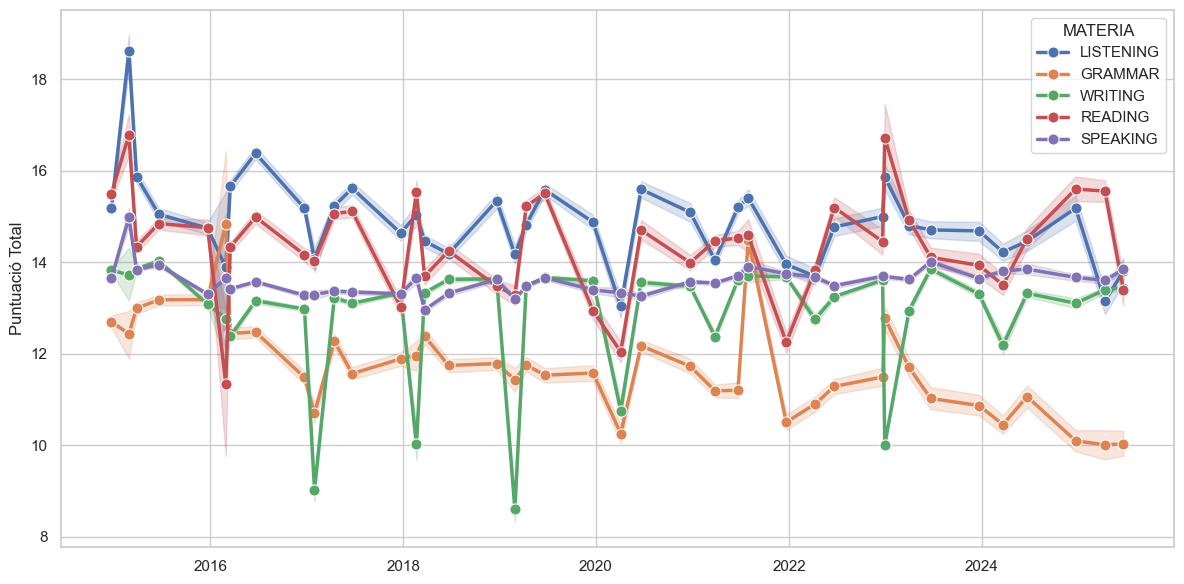

In [55]:

import seaborn as sns
import matplotlib.pyplot as plt

# Leer el archivo Excel
df = df_principal.copy()#pd.read_excel('df_principal_amb_edat.xlsx')

# Configurar el estilo de seaborn
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Gráfico de líneas para la evolución
sns.lineplot(data=df_principal, 
             x='DATA_EVALUACIO', 
             y='RESULT', 
             hue='MATERIA',
             marker='o',
             linewidth=2.5,                          
             markersize=8)

#plt.title('Evolució del Rendimient por Matèria', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Puntuació Total')
#plt.legend(title='Materias', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('C:\\temp\\evolucio_rendiment_per_materia.png',dpi=1200)
plt.show()

# headmap de correlacio

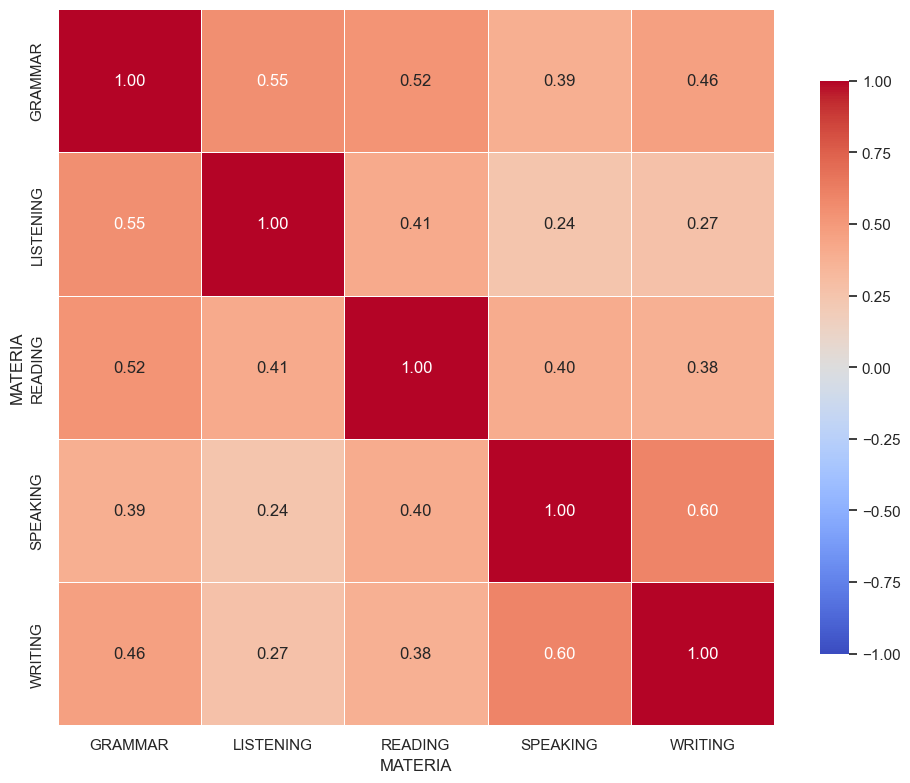

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df_pivot=df_principal.pivot_table(index='IDALUMNE', columns='MATERIA', values='RESULT')
df_pivot.reset_index(inplace=True)
df_pivot
# Calcular matriz de correlación
matriz_correlacion = df_pivot[['GRAMMAR','LISTENING','READING','SPEAKING','WRITING']].corr()  # method='spearman' pearson, kendall, spearman
matriz_correlacion 

# Crear el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, 
            annot=True,        # Muestra los valores numéricos
            cmap='coolwarm',   # Paleta de colores
            center=0,          # Centro del mapa de colores
            square=True,       # Celdas cuadradas
            fmt='.2f',         # Formato de 2 decimales
            linewidths=0.5,    # Ancho de línea entre celdas
            vmin=-1,           # Valor mínimo de la escala
            vmax=1,            # Valor máximo de la escala
            cbar_kws={'shrink': 0.8})  # Tamaño de la barra de colores

#plt.title('Matriz de Correlación - Habilidades del Idioma', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:\\temp\\matriz_correlacion_habilidades_idioma.png',dpi=1200)
plt.show()

# grafic correlacio amb plotly

In [57]:
import plotly.graph_objects as go
import plotly.express as px

# Calcular la matriz de correlación
matriz_correlacion = df_pivot[['GRAMMAR','LISTENING','READING','SPEAKING','WRITING']].corr()

# Crear el heatmap con Plotly
fig = go.Figure(data=go.Heatmap(
    z=matriz_correlacion.values,
    x=matriz_correlacion.columns,
    y=matriz_correlacion.columns,
    colorscale='RdBu_r',  # Puedes usar: 'Viridis', 'Plasma', 'Blues', 'RdBu', 'Portland', etc.
    zmin=-1,  # Mínimo valor para correlación
    zmax=1,   # Máximo valor para correlación
    hoverongaps=False,
    text=matriz_correlacion.round(2).values,  # Mostrar valores con 2 decimales
    texttemplate='%{text}',
    textfont={"size": 12},
    colorbar=dict(
        title='Correlación',
        title_side='right'
    )
))

# Personalizar el layout
fig.update_layout(
    title='Matriz de Correlación - Habilidades del Idioma',
    title_x=0.5,
    title_font=dict(size=20, family='Arial', color='black'),
    width=600,
    height=600,
    xaxis=dict(title='Habilidades'),
    yaxis=dict(title='Habilidades'),
    template='plotly_white'  # 'plotly', 'plotly_white', 'plotly_dark', 'ggplot2', etc.
)
fig.write_html("C:\\temp\\matriz_correlacion_habilidades_idioma_plotly.html")
fig.show()
df_pivot.head(5)


MATERIA,IDALUMNE,GRAMMAR,LISTENING,READING,SPEAKING,WRITING
0,30,10.566667,16.600000,10.466667,14.600000,14.666667
1,56,11.176471,14.976471,13.576471,13.882353,12.588235
2,66,9.175000,12.000000,16.425000,13.433333,11.200000
3,90,11.766667,14.800000,14.033333,14.333333,15.166667
4,155,8.666667,11.800000,11.980000,11.666667,12.583333


# REGRESIO LINEAL

# version graficos juntos

C:\Users\Usuario\AppData\Local\Temp\ipykernel_42156\3945728176.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


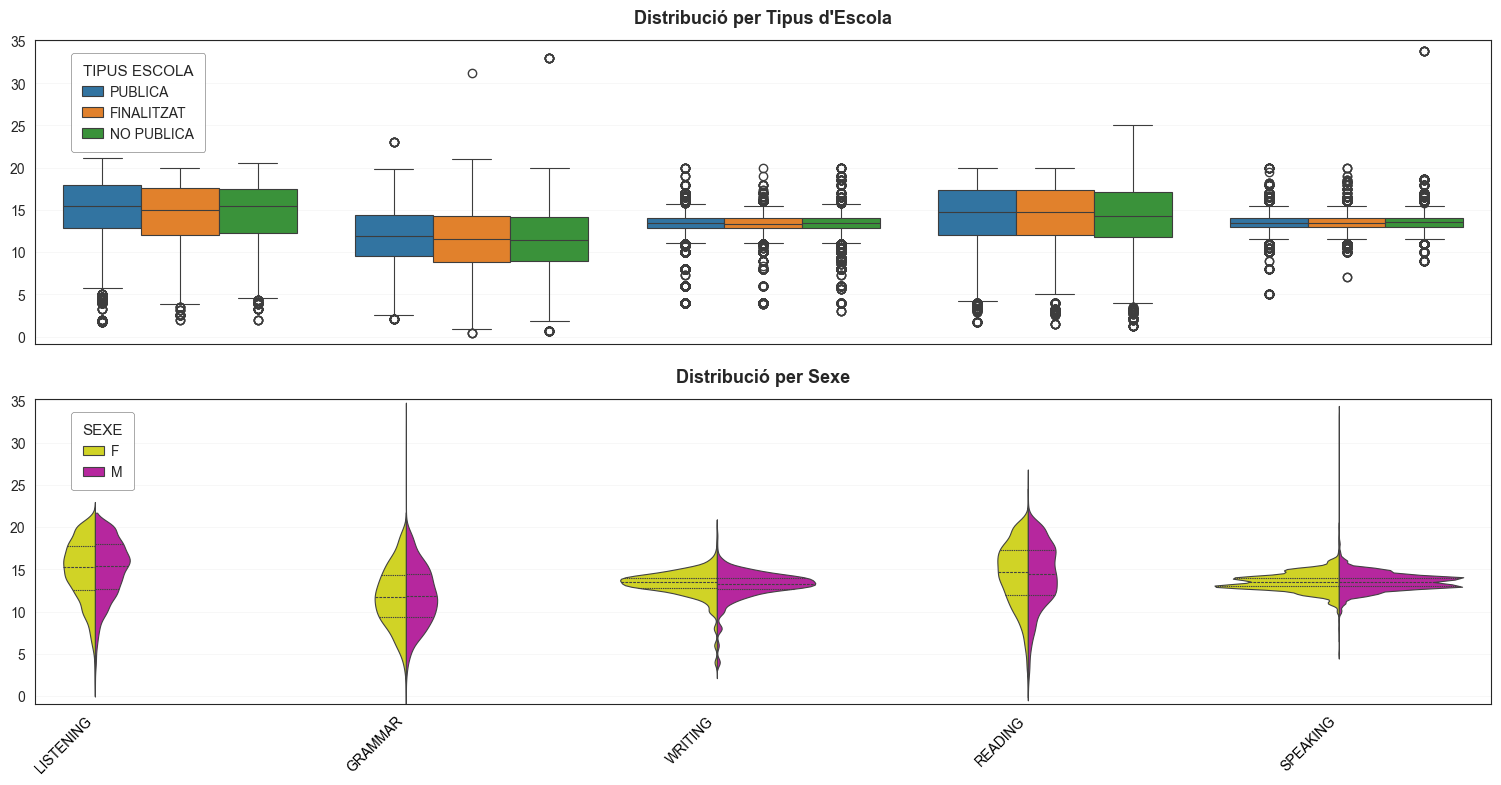

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Colores personalizados
colores_minimalistas = ['#1F77B4', '#FF7F0E', '#2CA02C']

# Estilo minimalista
plt.style.use('default')
sns.set_style("white")

# Crear figura más ancha
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Ajustar márgenes
plt.subplots_adjust(left=0.07, right=0.98, top=0.95, bottom=0.12, hspace=0.18)
df=df_principal.copy
# Gráfico 1: Boxplot (arriba)
box = sns.boxplot(data=df_principal, x='MATERIA', y='RESULT', hue='TIPUS_ESCOLA', 
                  palette=colores_minimalistas, ax=axes[0], linewidth=0.8)

# Configurar primer gráfico SIN etiquetas en eje X
axes[0].set_ylabel('')
axes[0].set_xlabel('')
axes[0].set_title('Distribució per Tipus d\'Escola', fontsize=13, pad=12, fontweight='bold')
axes[0].set_facecolor('white')
axes[0].grid(True, axis='y', alpha=0.2, linestyle='-', linewidth=0.5)
axes[0].tick_params(axis='x', which='both', bottom=False, labelbottom=False)  # Eliminar ticks y etiquetas

# Leyenda compacta en lado izquierdo superior
legend1 = axes[0].legend(title='TIPUS ESCOLA', frameon=True, 
                        loc='upper left',
                        bbox_to_anchor=(0.02, 0.98),  # Posición ajustada
                        fontsize=10,
                        title_fontsize=11,
                        framealpha=0.95,
                        borderpad=0.8,
                        handletextpad=0.5,
                        handlelength=1.5,
                        edgecolor='gray')
legend1.get_frame().set_linewidth(0.5)

# Gráfico 2: Violinplot (abajo)
colores_violint = ["#ECF009", "#CE0FAE"]
violin = sns.violinplot(data=df_principal, x='MATERIA', y='RESULT', hue='SEXO',
                        palette=colores_violint, ax=axes[1], linewidth=0.8, 
                        split=True, inner='quartile', bw_method=0.25)

# Configurar segundo gráfico CON etiquetas en eje X
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].set_title('Distribució per Sexe', fontsize=13, pad=12, fontweight='bold')
axes[1].set_facecolor('white')
axes[1].grid(True, axis='y', alpha=0.2, linestyle='-', linewidth=0.5)
axes[1].tick_params(axis='x', rotation=45, labelsize=10, labelcolor='black')

# Ajustar etiquetas del eje X para mejor legibilidad
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

# Leyenda compacta en lado izquierdo superior
legend2 = axes[1].legend(title='SEXE', frameon=True, 
                        loc='upper left',
                        bbox_to_anchor=(0.02, 0.98),  # Misma posición
                        fontsize=10,
                        title_fontsize=11,
                        framealpha=0.95,
                        borderpad=0.8,
                        handletextpad=0.5,
                        handlelength=1.5,
                        edgecolor='gray')
legend2.get_frame().set_linewidth(0.5)

# Sincronizar escalas Y
y_min = df_principal['RESULT'].min()
y_max = df_principal['RESULT'].max()
padding = (y_max - y_min) * 0.04

for ax in axes:
    ax.set_ylim(y_min - padding, y_max + padding)
    # Ajustar márgenes horizontales
    ax.margins(x=0.02)

plt.savefig('C:\\LLUIS\\Dropbox\\IT ACADEMY\Sprint13\\comparacio_vertical_leyenda_izquierda.png', dpi=1200, 
            bbox_inches='tight', facecolor='white',
            pad_inches=0.08)
plt.show()

# Aquí tienes cómo calcular el coeficiente de determinación (R²) para cada par de variables:

In [62]:
from scipy import stats

df_r2=df_principal.groupby('MATERIA')['RESULT'].mean().reset_index()
print(df_r2)
df_pivot22 = df_r2.pivot(columns='MATERIA', values='RESULT').reset_index(drop=True)
print(df_pivot22)

variables = ['GRAMMAR','LISTENING','READING','SPEAKING','WRITING']
r2_matrix = pd.DataFrame(index=variables, columns=variables)

df_gramar=df_principal[['IDALUMNE','MATERIA','RESULT']][df_principal['MATERIA']=='GRAMMAR']
df_speaking=df_principal[['IDALUMNE','MATERIA','RESULT']][df_principal['MATERIA']=='SPEAKING']
df_listening=df_principal[['IDALUMNE','MATERIA','RESULT']][df_principal['MATERIA']=='LISTENING']
df_reading=df_principal[['IDALUMNE','MATERIA','RESULT']][df_principal['MATERIA']=='READING']
df_writing=df_principal[['IDALUMNE','MATERIA','RESULT']][df_principal['MATERIA']=='WRITING']

df_gramar=df_gramar.groupby(['IDALUMNE','MATERIA'])['RESULT'].mean().reset_index()
df_speaking=df_speaking.groupby(['IDALUMNE','MATERIA'])['RESULT'].mean().reset_index()
df_listening=df_listening.groupby(['IDALUMNE','MATERIA'])['RESULT'].mean().reset_index()
df_reading=df_reading.groupby(['IDALUMNE','MATERIA'])['RESULT'].mean().reset_index()
df_writing=df_writing.groupby(['IDALUMNE','MATERIA'])['RESULT'].mean().reset_index()



     MATERIA     RESULT
0    GRAMMAR  11.808283
1  LISTENING  14.935560
2    READING  14.378096
3   SPEAKING  13.536251
4    WRITING  13.161738
MATERIA    GRAMMAR  LISTENING    READING   SPEAKING    WRITING
0        11.808283        NaN        NaN        NaN        NaN
1              NaN   14.93556        NaN        NaN        NaN
2              NaN        NaN  14.378096        NaN        NaN
3              NaN        NaN        NaN  13.536251        NaN
4              NaN        NaN        NaN        NaN  13.161738


In [63]:
from scipy import stats
import pandas as pd

# Lista de dataframes y sus nombres
dataframes = {
    'GRAMMAR': df_gramar,
    'LISTENING': df_listening, 
    'READING': df_reading,
    'SPEAKING': df_speaking,
    'WRITING': df_writing
}

# Calcular R² para cada par
results = []

for name1, df1 in dataframes.items():
    for name2, df2 in dataframes.items():
        if name1 < name2:  # Evitar duplicados y auto-comparaciones
            
            # Unir por IDALUMNE para obtener pares comunes
            merged = pd.merge(df1[['IDALUMNE', 'RESULT']], 
                             df2[['IDALUMNE', 'RESULT']], 
                             on='IDALUMNE', 
                             suffixes=('_1', '_2'))
            
            if len(merged) >= 2:  # Mínimo 2 puntos para regresión
                x = merged['RESULT_1'].values
                y = merged['RESULT_2'].values
                
                slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
                r2 = r_value ** 2
                n_alumnos = len(merged)
                
                results.append({
                    'Materia_1': name1,
                    'Materia_2': name2,
                    'R²': round(r2, 4),
                    'Correlación_r': round(r_value, 4),
                    'N_Alumnos_Comunes': n_alumnos
                })

# Crear DataFrame de resultados
df_results = pd.DataFrame(results)

# Ordenar por R² descendente
df_results = df_results.sort_values('R²', ascending=False)

print("RESULTADOS R² ENTRE MATERIAS:")
print("="*70)
print(f"{'Materia 1':<12} {'Materia 2':<12} {'R²':<8} {'Correlación':<12} {'N Alumnos':<12}")
print("-"*70)

for _, row in df_results.iterrows():
    print(f"{row['Materia_1']:<12} {row['Materia_2']:<12} {row['R²']:<8} {row['Correlación_r']:<12} {row['N_Alumnos_Comunes']:<12}")

print("="*70)

# Mostrar estadísticas resumidas
print(f"\nESTADÍSTICAS:")
print(f"Total de pares analizados: {len(df_results)}")
print(f"R² máximo: {df_results['R²'].max():.4f} ({df_results.iloc[0]['Materia_1']} vs {df_results.iloc[0]['Materia_2']})")
print(f"R² mínimo: {df_results['R²'].min():.4f} ({df_results.iloc[-1]['Materia_1']} vs {df_results.iloc[-1]['Materia_2']})")
print(f"R² promedio: {df_results['R²'].mean():.4f}")

# Mostrar las 5 combinaciones con mayor R²
print(f"\nTOP 5 COMBINACIONES CON MAYOR R²:")
print("-" * 50)
for i, row in df_results.head().iterrows():
    print(f"{row['Materia_1']} - {row['Materia_2']}: R² = {row['R²']:.4f} (r = {row['Correlación_r']:.4f})")

RESULTADOS R² ENTRE MATERIAS:
Materia 1    Materia 2    R²       Correlación  N Alumnos   
----------------------------------------------------------------------
SPEAKING     WRITING      0.3615   0.6013       807         
GRAMMAR      LISTENING    0.3014   0.549        839         
GRAMMAR      READING      0.2753   0.5247       838         
GRAMMAR      WRITING      0.2155   0.4642       819         
LISTENING    READING      0.1686   0.4106       837         
READING      SPEAKING     0.1596   0.3995       824         
GRAMMAR      SPEAKING     0.1515   0.3893       825         
READING      WRITING      0.1441   0.3796       817         
LISTENING    WRITING      0.0714   0.2672       819         
LISTENING    SPEAKING     0.0587   0.2422       824         

ESTADÍSTICAS:
Total de pares analizados: 10
R² máximo: 0.3615 (SPEAKING vs WRITING)
R² mínimo: 0.0587 (LISTENING vs SPEAKING)
R² promedio: 0.1908

TOP 5 COMBINACIONES CON MAYOR R²:
----------------------------------------------

# Versión solo con las relaciones fuertes

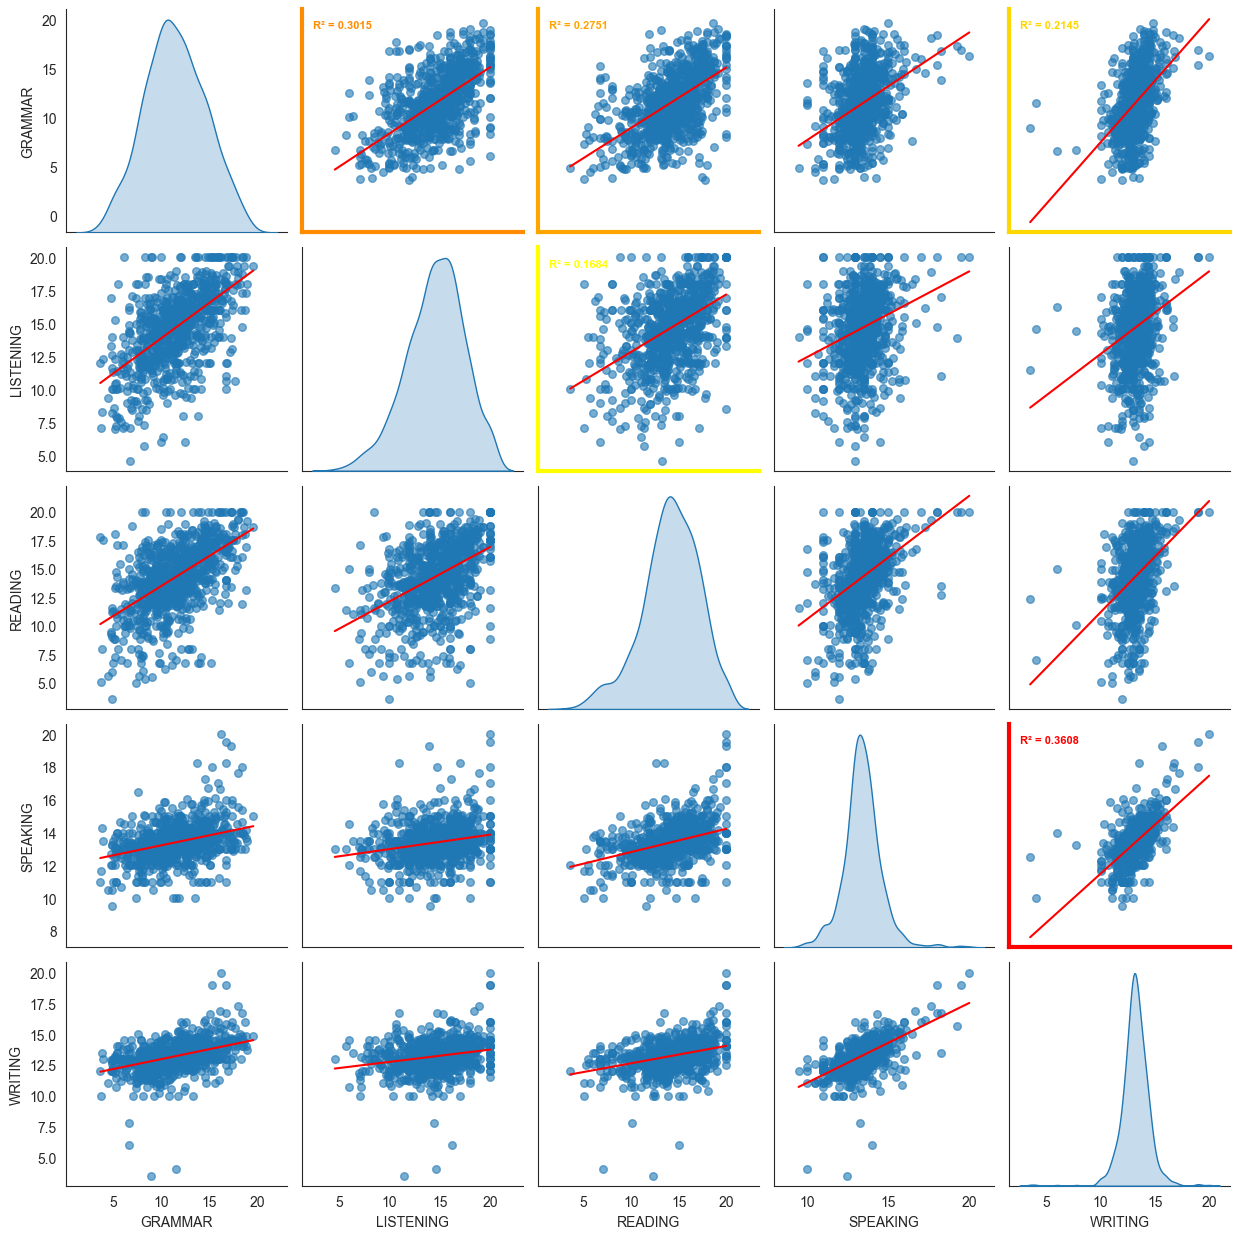

In [66]:
# Primero, limpiar los datos
df_clean = df_pivot[['GRAMMAR','LISTENING','READING','SPEAKING','WRITING']].dropna()

# Crear el pairplot con configuración más robusta
g = sns.pairplot(df_clean,
                 kind='reg',
                 diag_kind='kde',
                 plot_kws={
                     'scatter_kws': {'alpha': 0.6, 's': 30},
                     'line_kws': {'color': 'red', 'linewidth': 1.5},
                     'robust': True,  # Usar regresión robusta
                     'ci': None       # No calcular intervalos de confianza
                 },
                 corner=False)

# Resaltar las relaciones fuertes
strong_pairs = [
    ('SPEAKING', 'WRITING'),
    ('GRAMMAR', 'LISTENING'), 
    ('GRAMMAR', 'READING'),
    ('GRAMMAR', 'WRITING'),
    ('LISTENING', 'READING')
]

# Colores para diferentes niveles de fuerza
color_map = {
    ('SPEAKING', 'WRITING'): 'red',
    ('GRAMMAR', 'LISTENING'): 'darkorange', 
    ('GRAMMAR', 'READING'): 'orange',
    ('GRAMMAR', 'WRITING'): 'gold',
    ('LISTENING', 'READING'): 'yellow'
}

# Resaltar las relaciones fuertes
for i, row_var in enumerate(['GRAMMAR','LISTENING','READING','SPEAKING','WRITING']):
    for j, col_var in enumerate(['GRAMMAR','LISTENING','READING','SPEAKING','WRITING']):
        if i != j:
            pair = (row_var, col_var)
            reverse_pair = (col_var, row_var)
            
            if pair in strong_pairs:
                color = color_map[pair]
                ax = g.axes[i, j]
                # Dibujar un cuadro alrededor
                for spine in ax.spines.values():
                    spine.set_edgecolor(color)
                    spine.set_linewidth(3)
                
                # Añadir texto con R²
                r_squared_dict = {
                    ('SPEAKING', 'WRITING'): 'R² = 0.3608',
                    ('GRAMMAR', 'LISTENING'): 'R² = 0.3015',
                    ('GRAMMAR', 'READING'): 'R² = 0.2751',
                    ('GRAMMAR', 'WRITING'): 'R² = 0.2145',
                    ('LISTENING', 'READING'): 'R² = 0.1684'
                }
                
                r_text = r_squared_dict.get(pair, '')
                ax.text(0.05, 0.95, r_text, transform=ax.transAxes, 
                       fontsize=8, color=color, fontweight='bold',
                       verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

#plt.suptitle('Pairplot - Relaciones Fuertes Resaltadas', y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig('C:\\temp\\pairplot_relaciones_fuertes_resaltadas.png',dpi=1200)
plt.show()